In [2]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable


## *Аналіз даних*

Перші 5 рядків:
   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000     5850         3        1        2      yes      no   
1         2  38500     4000         2        1        1      yes      no   
2         3  49500     3060         3        1        1      yes      no   
3         4  60500     6650         3        1        2      yes     yes   
4         5  61000     6360         2        1        1      yes      no   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         0       no  
2       no    no    no         0       no  
3       no    no    no         0       no  
4       no    no    no         0       no  

Інформація про дані:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 546 entries, 0 to 545
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   rownames  546 non-null    int64 
 1   price     546 non

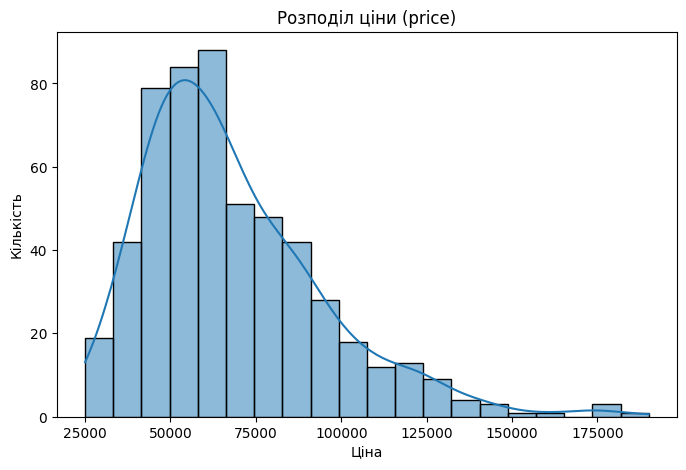

Дані з пропусками:
   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000     5850       NaN        1        2      yes      no   
1         2  38500     4000       2.0        1        1      yes      no   
2         3  49500     3060       3.0        1        1      NaN      no   
3         4  60500     6650       3.0        1        2      yes     yes   
4         5  61000     6360       2.0        1        1      yes      no   

  fullbase gashw airco  garagepl prefarea  
0      yes    no    no         1       no  
1       no    no    no         0       no  
2       no    no    no         0       no  
3       no    no    no         0       no  
4       no    no    no         0       no  


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('housing.csv')

print("Перші 5 рядків:")
print(df.head())

print("\nІнформація про дані:")
print(df.info())

print("\nОписова статистика:")
print(df.describe())

cat_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']
print("\nУнікальні значення в категоріальних колонках:")
for col in cat_cols:
    print(f"{col}: {df[col].unique()}")

plt.figure(figsize=(8, 5))
sns.histplot(df['price'], bins=20, kde=True)
plt.title('Розподіл ціни (price)')
plt.xlabel('Ціна')
plt.ylabel('Кількість')
plt.show()

df.loc[0, 'bedrooms'] = np.nan
df.loc[2, 'driveway'] = np.nan

print("Дані з пропусками:")
print(df.head())

## *Попередня обробка даних:*

## *Обробка категоріальних ознак методом Factorize*

In [30]:
cat_cols = ['driveway', 'recroom', 'fullbase', 'gashw', 'airco', 'prefarea']

for col in cat_cols:
    df[col + '_fact'], _ = pd.factorize(df[col])
    
print("\nПісля Factorize:")
print(df[[col for col in df.columns if 'fact' in col]].head())


Після Factorize:
   driveway_fact  recroom_fact  fullbase_fact  gashw_fact  airco_fact  \
0              0             0              0           0           0   
1              0             0              1           0           0   
2             -1             0              1           0           0   
3              0             1              1           0           0   
4              0             0              1           0           0   

   prefarea_fact  
0              0  
1              0  
2              0  
3              0  
4              0  


## *Обробка категоріальних ознак методом One-hot encoding*

In [48]:
df_onehot = pd.get_dummies(df[cat_cols], drop_first=True)  

print("\nПісля One-hot encoding:")
print(df_onehot.head())


Після One-hot encoding:
   driveway_yes  recroom_yes  fullbase_yes  gashw_yes  airco_yes  prefarea_yes
0          True        False          True      False      False         False
1          True        False         False      False      False         False
2          True        False         False      False      False         False
3          True         True         False      False      False         False
4          True        False         False      False      False         False


## *Масштабування ознак за допомогою MinMaxScaler*

In [49]:
num_cols = ['lotsize', 'bedrooms', 'bathrms', 'stories', 'garagepl']

scaler_minmax = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[num_cols] = scaler_minmax.fit_transform(df[num_cols])

print("\nПісля MinMaxScaler:")
print(df_minmax_scaled[num_cols].head())


Після MinMaxScaler:
    lotsize  bedrooms  bathrms   stories  garagepl
0  0.288660  0.393028      0.0  0.333333  0.333333
1  0.161512  0.200000      0.0  0.000000  0.000000
2  0.096907  0.400000      0.0  0.000000  0.000000
3  0.343643  0.400000      0.0  0.333333  0.000000
4  0.323711  0.200000      0.0  0.000000  0.000000


## *Масштабування ознак за допомогою StandardScaler*

In [40]:
scaler_std = StandardScaler()
df_std_scaled = df.copy()
df_std_scaled[num_cols] = scaler_std.fit_transform(df[num_cols])

print("\nПісля StandardScaler:")
print(df_std_scaled[num_cols].head())


Після StandardScaler:
    lotsize  bedrooms   bathrms   stories  garagepl
0  0.323028  0.000000 -0.569495  0.221704  0.357567
1 -0.531013 -1.310063 -0.569495 -0.931157 -0.804525
2 -0.964958  0.047322 -0.569495 -0.931157 -0.804525
3  0.692343  0.047322 -0.569495  0.221704 -0.804525
4  0.558466 -1.310063 -0.569495 -0.931157 -0.804525


## *Використання SimpleImputer для заповнення відсутніх значень*

In [41]:
num_imputer = SimpleImputer(strategy='mean')
cat_imputer = SimpleImputer(strategy='most_frequent')

df[num_cols] = num_imputer.fit_transform(df[num_cols])

df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("\nПісля заповнення пропусків:")
print(df.head())


Після заповнення пропусків:
   rownames  price  lotsize  bedrooms  bathrms  stories driveway recroom  \
0         1  42000   5850.0  2.965138      1.0      2.0      yes      no   
1         2  38500   4000.0  2.000000      1.0      1.0      yes      no   
2         3  49500   3060.0  3.000000      1.0      1.0      yes      no   
3         4  60500   6650.0  3.000000      1.0      2.0      yes     yes   
4         5  61000   6360.0  2.000000      1.0      1.0      yes      no   

  fullbase gashw  ... recroom_fact  fullbase_fact gashw_fact  airco_fact  \
0      yes    no  ...            0              0          0           0   
1       no    no  ...            0              1          0           0   
2       no    no  ...            0              1          0           0   
3       no    no  ...            1              1          0           0   
4       no    no  ...            0              1          0           0   

   prefarea_fact  total_rooms  has_driveway  large_lot  f

## *Формування ознак*

In [42]:
df['total_rooms'] = df['bedrooms'] + df['bathrms']

df['has_driveway'] = df['driveway'].map({'yes': 1, 'no': 0})

median_lotsize = df['lotsize'].median()
df['large_lot'] = (df['lotsize'] > median_lotsize).astype(int)

df['fullbase_flag'] = df['fullbase'].map({'yes': 1, 'no': 0})
df['age_stories'] = df['stories'] * df['fullbase_flag']

print(df[['total_rooms', 'has_driveway', 'large_lot', 'age_stories']].head())

   total_rooms  has_driveway  large_lot  age_stories
0     3.965138             1          1          2.0
1     3.000000             1          0          0.0
2     4.000000             1          0          0.0
3     4.000000             1          1          0.0
4     3.000000             1          1          0.0


## *Розбиття даних на тренувальний і тестовий набір*

In [37]:
X = df.drop(columns=['price', 'rownames'])  
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Розмір тренувального набору: {X_train.shape[0]} зразків")
print(f"Розмір тестового набору: {X_test.shape[0]} зразків")

Розмір тренувального набору: 436 зразків
Розмір тестового набору: 110 зразків


## *Поняття "перенавчання" і "недонавчання"*

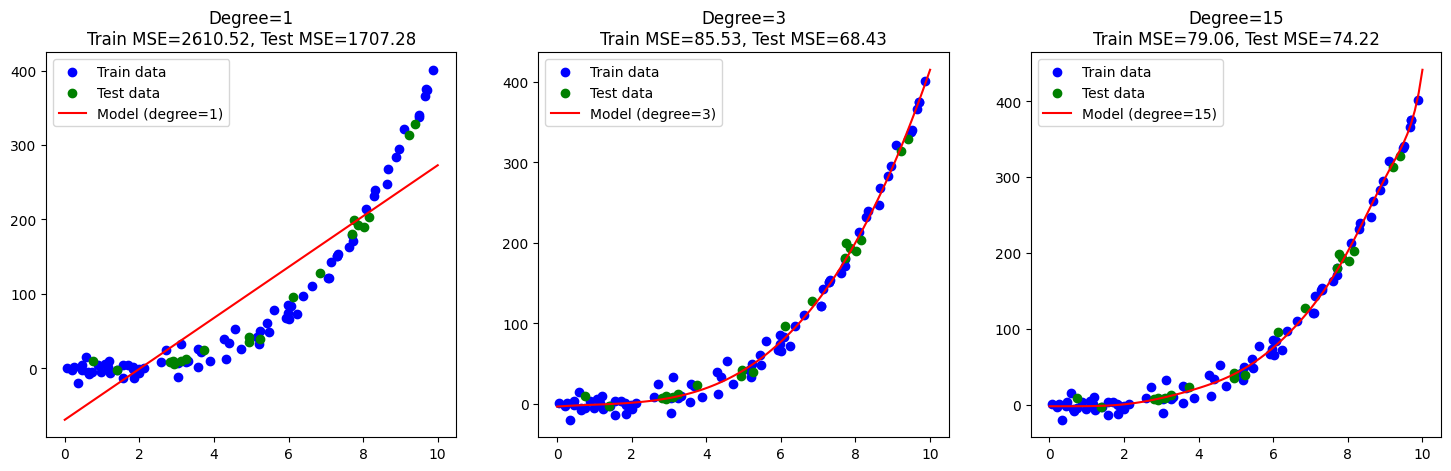

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

np.random.seed(42)
X = np.sort(np.random.rand(100) * 10).reshape(-1, 1)
y = 0.5 * X**3 - X**2 + X + np.random.normal(scale=10, size=X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

def train_and_evaluate(degree):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_error = mean_squared_error(y_train, y_train_pred)
    test_error = mean_squared_error(y_test, y_test_pred)
    return y_train_pred, y_test_pred, train_error, test_error, model

degrees = [1, 3, 15] 

plt.figure(figsize=(18, 5))
for i, degree in enumerate(degrees, 1):
    y_train_pred, y_test_pred, train_err, test_err, model = train_and_evaluate(degree)

    plt.subplot(1, 3, i)
    plt.scatter(X_train, y_train, color='blue', label='Train data')
    plt.scatter(X_test, y_test, color='green', label='Test data')
    
    X_plot = np.linspace(0, 10, 100).reshape(-1, 1)
    y_plot = model.predict(X_plot)
    plt.plot(X_plot, y_plot, color='red', label=f'Model (degree={degree})')
    
    plt.title(f'Degree={degree}\nTrain MSE={train_err:.2f}, Test MSE={test_err:.2f}')
    plt.legend()

plt.show()

In [51]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(42)
X = np.sort(np.random.rand(100) * 10).reshape(-1, 1) 
y = 0.5 * X.flatten()**3 - X.flatten()**2 + X.flatten() + np.random.normal(scale=10, size=100)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores = []

for train_index, test_index in kf.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)

print(f"Середній R² (5-fold CV): {np.mean(r2_scores):.4f}")

Середній R² (5-fold CV): 0.7996


## *Поліноміальна регресія*

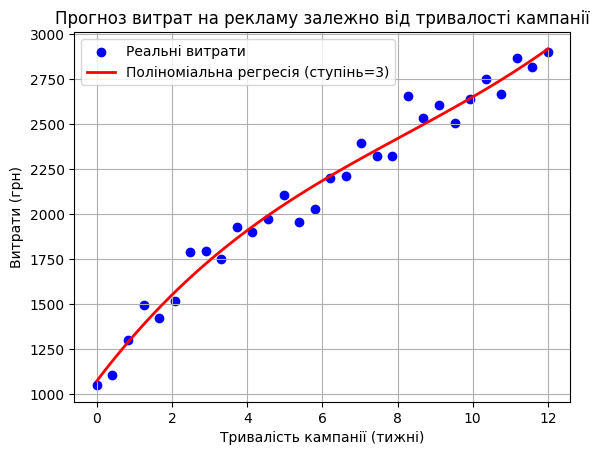

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

weeks = np.linspace(0, 12, 30).reshape(-1, 1) 
np.random.seed(42)
costs = 1000 + 300 * weeks - 20 * weeks**2 + 0.7 * weeks**3 + np.random.normal(0, 100, size=(30, 1))

degree = 3
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(weeks, costs)

weeks_grid = np.linspace(0, 12, 100).reshape(-1, 1)
predicted_costs = model.predict(weeks_grid)

plt.scatter(weeks, costs, color='blue', label='Реальні витрати')
plt.plot(weeks_grid, predicted_costs, color='red', linewidth=2, label='Поліноміальна регресія (ступінь=3)')
plt.title('Прогноз витрат на рекламу залежно від тривалості кампанії')
plt.xlabel('Тривалість кампанії (тижні)')
plt.ylabel('Витрати (грн)')
plt.legend()
plt.grid(True)
plt.show()

## *L1*

Lasso coefficients:
Канал 1: 15008.73
Канал 2: -12.99
Канал 3: -120.07
Канал 4: 25812.70
Канал 5: 28.64
Канал 6: 35.68
Канал 7: 53372.76
Канал 8: -148.09
Канал 9: -41.22
Канал 10: 73.93


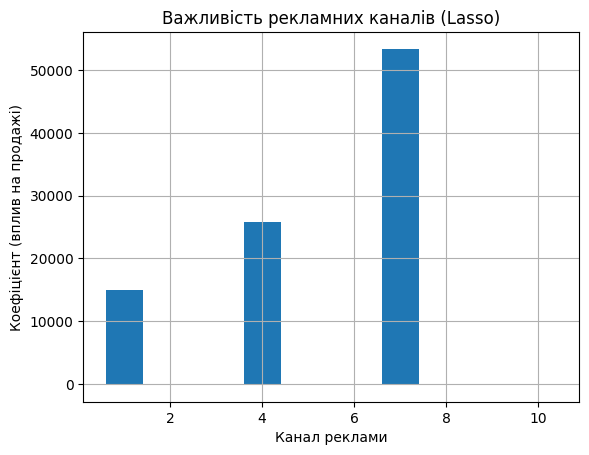

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_samples = 100
n_features = 10

X = np.random.rand(n_samples, n_features) * 1000

true_coefs = np.array([50, 0, 0, 100, 0, 0, 200, 0, 0, 0])
y = X @ true_coefs + np.random.normal(0, 1000, size=n_samples)  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lasso = Lasso(alpha=0.1) 
lasso.fit(X_train_scaled, y_train)

print("Lasso coefficients:")
for i, coef in enumerate(lasso.coef_):
    print(f"Канал {i+1}: {coef:.2f}")

plt.bar(range(1, n_features+1), lasso.coef_)
plt.xlabel('Канал реклами')
plt.ylabel('Коефіцієнт (вплив на продажі)')
plt.title('Важливість рекламних каналів (Lasso)')
plt.grid(True)
plt.show()


## *L2*

Ridge coefficients:
Канал 1: 13188.28
Канал 2: 9574.73
Канал 3: 7400.70
Канал 4: 25783.24
Канал 5: 16775.94
Канал 6: 5196.28
Канал 7: 2749.66
Канал 8: 4496.72
Канал 9: 13377.19
Канал 10: 25755.70


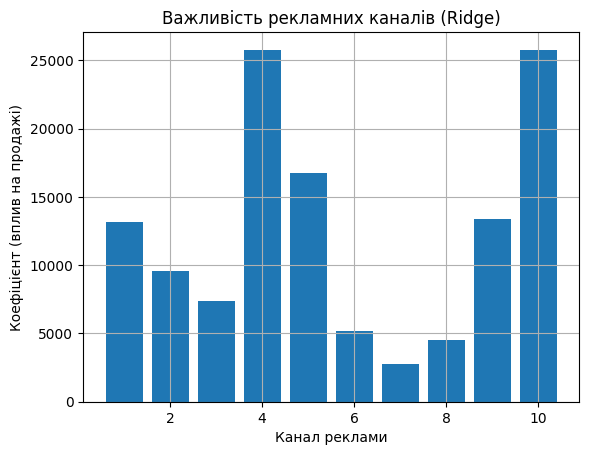

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
n_samples = 100
n_features = 10

X_base = np.random.rand(n_samples, 8) * 1000

channel_9 = X_base[:, 0] * 0.95 + np.random.normal(0, 20, n_samples) 
channel_10 = X_base[:, 3] * 0.9 + np.random.normal(0, 20, n_samples) 

X = np.column_stack([X_base, channel_9, channel_10])

true_coefs = np.array([50, 40, 30, 100, 60, 20, 10, 15, 48, 92])
y = X @ true_coefs + np.random.normal(0, 1000, n_samples)  # продажі + шум

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=10) 
ridge.fit(X_train_scaled, y_train)

print("Ridge coefficients:")
for i, coef in enumerate(ridge.coef_):
    print(f"Канал {i+1}: {coef:.2f}")

plt.bar(range(1, n_features + 1), ridge.coef_)
plt.xlabel('Канал реклами')
plt.ylabel('Коефіцієнт (вплив на продажі)')
plt.title('Важливість рекламних каналів (Ridge)')
plt.grid(True)
plt.show()